In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [2]:
df = pd.read_csv("datafile (1).csv")

In [3]:
df.head()

,Crop,State,Cost of Cultivation (`/Hectare) A2+FL,Cost of Cultivation (`/Hectare) C2,Cost of Production (`/Quintal) C2,Yield (Quintal/ Hectare)
0,ARHAR,Uttar Pradesh,9794.05,23076.74,1941.55,9.83
1,ARHAR,Karnataka,10593.15,16528.68,2172.46,7.47
2,ARHAR,Gujarat,13468.82,19551.90,1898.30,9.59
3,ARHAR,Andhra Pradesh,17051.66,24171.65,3670.54,6.42
4,ARHAR,Maharashtra,17130.55,25270.26,2775.80,8.72


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 49 entries, 0 to 48
Data columns (total 6 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Crop                                   49 non-null     str    
 1   State                                  49 non-null     str    
 2   Cost of Cultivation (`/Hectare) A2+FL  49 non-null     float64
 3   Cost of Cultivation (`/Hectare) C2     49 non-null     float64
 4   Cost of Production (`/Quintal) C2      49 non-null     float64
 5   Yield (Quintal/ Hectare)               49 non-null     float64
dtypes: float64(4), str(2)
memory usage: 3.3 KB


In [5]:
df.isnull().sum()

Crop                                     0
State                                    0
Cost of Cultivation (`/Hectare) A2+FL    0
Cost of Cultivation (`/Hectare) C2       0
Cost of Production (`/Quintal) C2        0
Yield (Quintal/ Hectare)                 0
dtype: int64

In [6]:
df.describe()


,Cost of Cultivation (`/Hectare) A2+FL,Cost of Cultivation (`/Hectare) C2,Cost of Production (`/Quintal) C2,Yield (Quintal/ Hectare)
count,49.000000,49.000000,49.000000,49.000000
mean,20363.537347,31364.666735,1620.537755,98.086735
std,13561.435306,20095.783569,1104.990472,245.293123
min,5483.540000,7868.640000,85.790000,1.320000
25%,12774.410000,19259.840000,732.620000,9.590000
50%,17022.000000,25909.050000,1595.560000,13.700000
75%,24731.060000,35423.480000,2228.970000,36.610000
max,66335.060000,91442.630000,5777.480000,1015.450000


In [7]:
df["Crop"].unique()

<ArrowStringArray>
[               'ARHAR',               'COTTON',                 'GRAM',
            'GROUNDNUT',                'MAIZE',                'MOONG',
                'PADDY', 'RAPESEED AND MUSTARD',            'SUGARCANE',
                'WHEAT']
Length: 10, dtype: str

In [8]:
df["Crop"].nunique()

10

In [9]:
from sklearn.preprocessing import LabelEncoder

le_crop = LabelEncoder()
le_state = LabelEncoder()

df["Crop"] = le_crop.fit_transform(df["Crop"])
df["State"] = le_state.fit_transform(df["State"])

In [10]:
df.head()

,Crop,State,Cost of Cultivation (`/Hectare) A2+FL,Cost of Cultivation (`/Hectare) C2,Cost of Production (`/Quintal) C2,Yield (Quintal/ Hectare)
0,0,11,9794.05,23076.74,1941.55,9.83
1,0,4,10593.15,16528.68,2172.46,7.47
2,0,2,13468.82,19551.90,1898.30,9.59
3,0,0,17051.66,24171.65,3670.54,6.42
4,0,6,17130.55,25270.26,2775.80,8.72


In [11]:
print(df.columns.tolist())

['Crop', 'State', 'Cost of Cultivation (`/Hectare) A2+FL', 'Cost of Cultivation (`/Hectare) C2', 'Cost of Production (`/Quintal) C2', 'Yield (Quintal/ Hectare) ']


In [12]:
for i, col in enumerate(df.columns):
    print(i, ":", col)

0 : Crop
1 : State
2 : Cost of Cultivation (`/Hectare) A2+FL
3 : Cost of Cultivation (`/Hectare) C2
4 : Cost of Production (`/Quintal) C2
5 : Yield (Quintal/ Hectare) 


In [13]:
for col in df.columns:
    print(repr(col))

'Crop'
'State'
'Cost of Cultivation (`/Hectare) A2+FL'
'Cost of Cultivation (`/Hectare) C2'
'Cost of Production (`/Quintal) C2'
'Yield (Quintal/ Hectare) '


In [14]:
X = df.drop("Yield (Quintal/ Hectare) ", axis=1)
y = df["Yield (Quintal/ Hectare) "]

In [15]:
df.columns = df.columns.str.strip()

In [16]:
X = df.drop("Yield (Quintal/ Hectare)", axis=1)
y = df["Yield (Quintal/ Hectare)"]

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [18]:
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [19]:
y_pred = model.predict(X_test)

print(y_pred)

[  8.8966  49.7925  46.855  797.3447  16.5054   6.3088   7.2594   6.8473
  38.1995  14.3888]


In [20]:
print("MAE :", mean_absolute_error(y_test, y_pred))
print("MSE :", mean_squared_error(y_test, y_pred))
print("R2 Score :", r2_score(y_test, y_pred))

MAE : 28.44186
MSE : 4852.737441883998
R2 Score : 0.9462821994110897


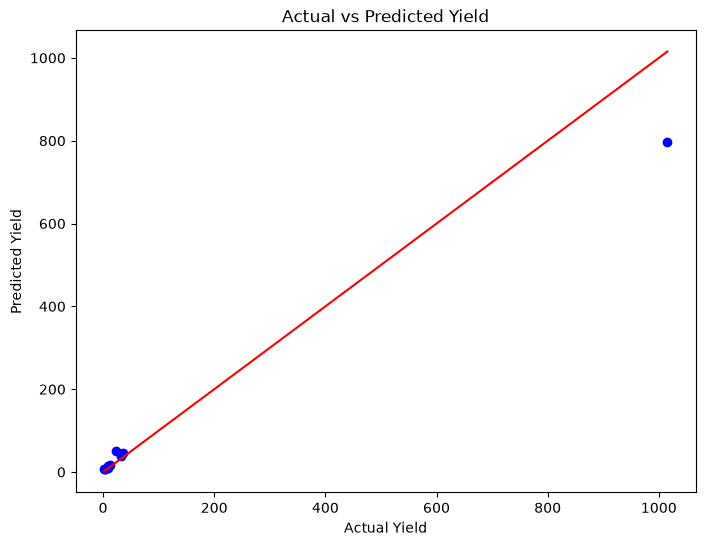

In [21]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred, color='blue')

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red'
)

plt.xlabel("Actual Yield")
plt.ylabel("Predicted Yield")
plt.title("Actual vs Predicted Yield")

plt.show()

In [22]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

                                 Feature  Importance
4      Cost of Production (`/Quintal) C2    0.713173
2  Cost of Cultivation (`/Hectare) A2+FL    0.133570
3     Cost of Cultivation (`/Hectare) C2    0.122396
0                                   Crop    0.017724
1                                  State    0.013136


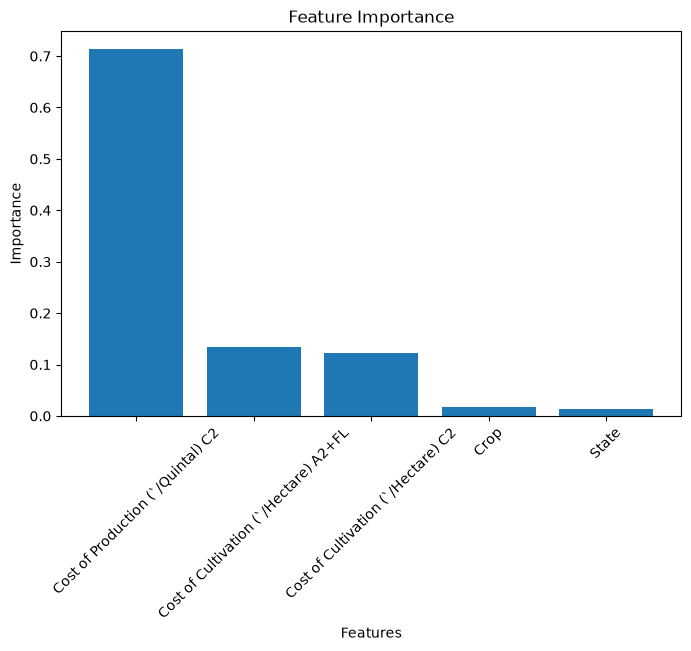

In [23]:
plt.figure(figsize=(8,5))

plt.bar(
    importance["Feature"],
    importance["Importance"]
)

plt.xticks(rotation=45)
plt.xlabel("Features")
plt.ylabel("Importance")
plt.title("Feature Importance")

plt.show()

# Prediction of Agriculture Crop Production in India

## Internship Project

### Objective
The objective of this project is to predict crop yield based on cultivation cost, production cost, crop type, and state using Machine Learning. A Random Forest Regressor model is used to improve prediction accuracy.

## Step 1: Import Required Libraries

## Step 2: Load the Dataset

## Step 3: Explore the Dataset

## Step 4: Data Preprocessing

## Step 5: Feature Selection

## Step 6: Split Dataset into Training and Testing Sets

## Step 7: Train Random Forest Regressor

## Step 8: Make Predictions

## Step 9: Evaluate the Model

## Step 10: Feature Importance Analysis

# Conclusion

The Random Forest Regression model successfully predicted agricultural crop yield using crop type, state, cultivation cost, and production cost.

Model Performance:

- Mean Absolute Error (MAE): 28.44
- Mean Squared Error (MSE): 4852.74
- R² Score: 0.9463

The high R² score indicates that the model explains approximately 94.63% of the variation in crop yield, demonstrating strong predictive performance.